### Modules and Dependencies

In [43]:
%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")

### Functions to get the ZTE data
`generate_zte_data(ksp, coord,n_missing,undersampling_factor=1)`

### Single and Multi-Channel Gridding Functions
`gridding_one_coil(kspace_data, coord)` and `gridding_operator(kspace_data, coord)`

### Multi-Channel De-Gridding Function
`gridding_operator_H(cartesian_data,coord)`

In [28]:
import aymansigmri as asm

In [29]:
zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=0, undersampling_factor=1)

kspace_cart_coils = asm.gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)
#radial_interp_coils = asm.gridding_operator_H(cartesian_data=kspace_cart_coils, coord=zte_radial_coords)

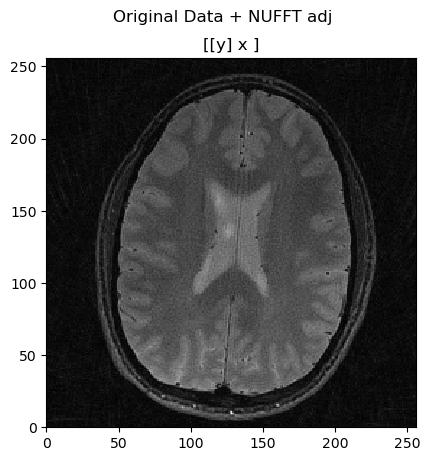

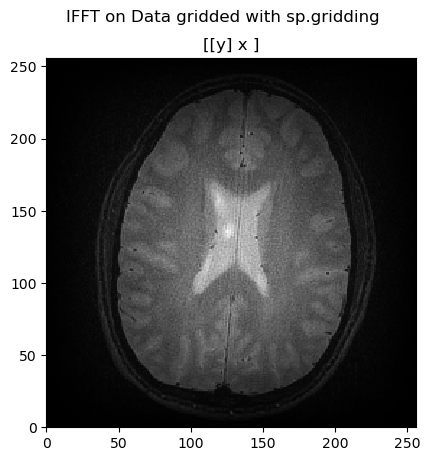

In [30]:
zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=0, undersampling_factor=1)

kspace_cart_coils = asm.gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)

dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)
zte_img_grid = sp.nufft_adjoint(zte_radial_kspace * dcf, zte_radial_coords)
zte_img_rss = np.sum(np.abs(zte_img_grid)**2, axis=0)**0.5
pl.ImagePlot(zte_img_rss, title='Original Data + NUFFT adj')

img_cart_grid = sp.ifft(kspace_cart_coils)
img_rss_cart = np.sum(np.abs(img_cart_grid)**2, axis=0)**0.5
pl.ImagePlot(img_rss_cart, title='IFFT on Data gridded with sp.gridding')    

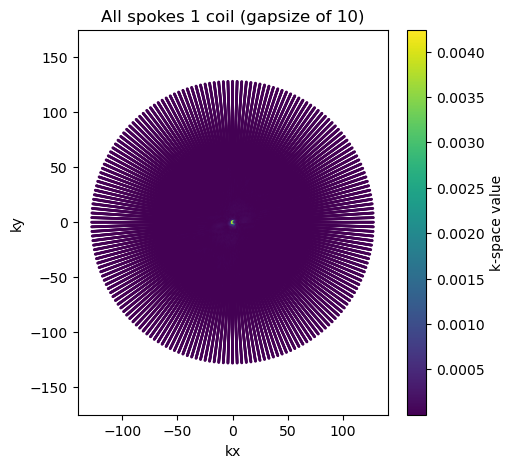

In [31]:
all_coords = zte_radial_coords.reshape(-1,2)
all_kspace = zte_radial_kspace[0].reshape(-1)

plt.figure(figsize=(5, 5))
plt.scatter(all_coords[:, 0], all_coords[:, 1],c=np.abs(all_kspace),s=1)
plt.colorbar(label='k-space value')
plt.title('All spokes 1 coil (gapsize of 10)')
plt.xlabel('kx')
plt.ylabel('ky')
plt.axis('equal')

plt.show()

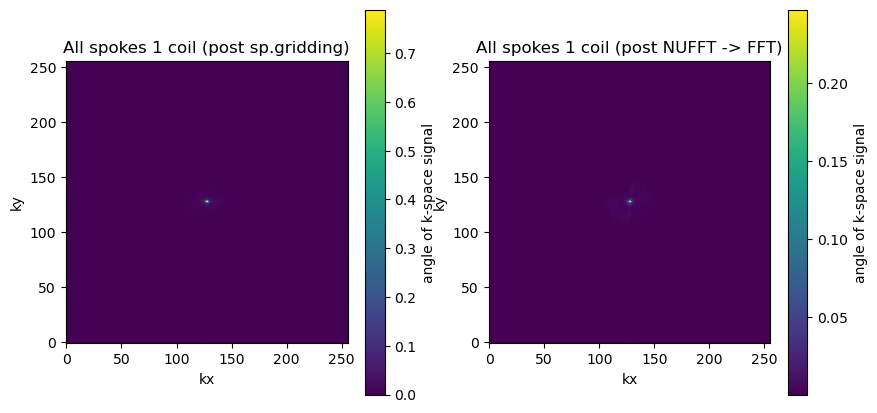

In [32]:
zte_cart_kspace_imgtrip = asm.nufft_gridding(kspace=zte_radial_kspace, coords=zte_radial_coords)

kspace_cart_coils = asm.gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))


im0 = ax[0].imshow(np.abs(kspace_cart_coils[0]), origin='lower')
fig.colorbar(im0, ax=ax[0], label='angle of k-space signal')
ax[0].set_title('All spokes 1 coil (post sp.gridding)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
im1 = ax[1].imshow(np.abs(zte_cart_kspace_imgtrip[0]), origin='lower')
fig.colorbar(im1, ax=ax[1], label='angle of k-space signal')
ax[1].set_title('All spokes 1 coil (post NUFFT -> FFT)')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')


plt.show()

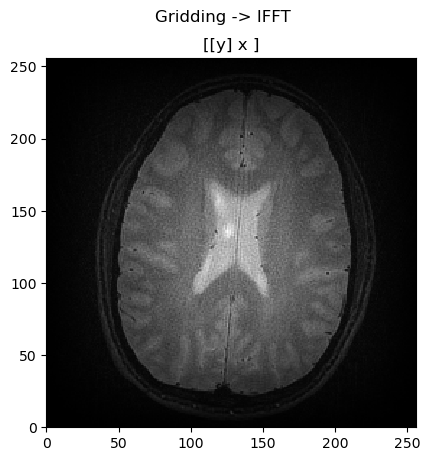

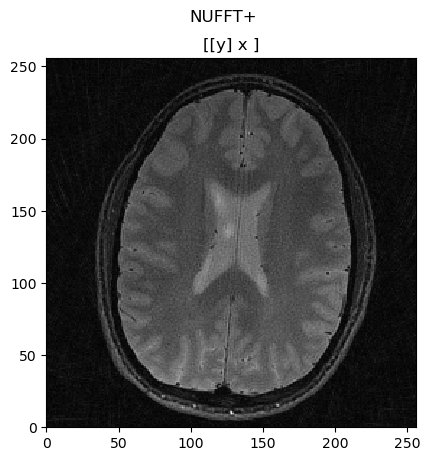

In [33]:
im_grid_gridding = sp.ifft(kspace_cart_coils)
im_rss_gridding = np.sum(np.abs(im_grid_gridding)**2, axis=0)**0.5


#pl.ImagePlot(im_grid, z=0)
pl.ImagePlot(im_rss_gridding, title='Gridding -> IFFT')

im_grid_img_trip = sp.ifft(zte_cart_kspace_imgtrip)
im_rss_trip = np.sum(np.abs(im_grid_img_trip)**2, axis=0)**0.5

#pl.ImagePlot(im_grid, z=0)
pl.ImagePlot(im_rss_trip, title='NUFFT+')

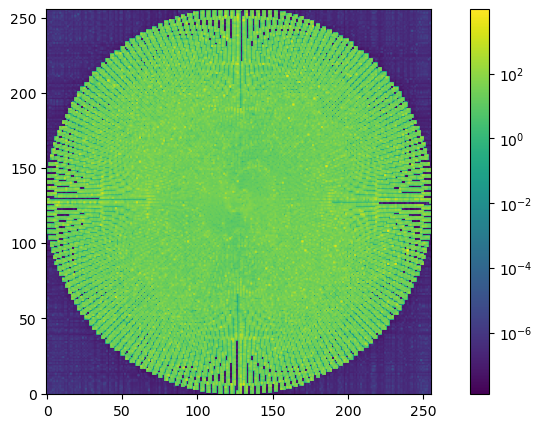

In [34]:
scaling = ((kspace_cart_coils + 1e-12) /(zte_cart_kspace_imgtrip + 1e-12))*10

fig = plt.figure(figsize=(10,5))
im1 = plt.imshow(np.abs(scaling[0]), origin='lower', norm='log')

plt.colorbar(im1)
plt.show()

im_grid_div = sp.ifft(scaling)
im_rss_div = np.sum(np.abs(im_grid_div)**2, axis=0)**2


In [35]:
flat = np.abs(scaling[0]).ravel()
print(f"mean: {np.mean(flat)}, median: {np.median(flat)}, 25 percentile: {np.percentile(flat, 25)}, 75 percentile: {np.percentile(flat, 75)}")

mean: 26.9540416684402, median: 16.81213344338592, 25 percentile: 3.229745847685159e-07, 75 percentile: 32.12089849761693


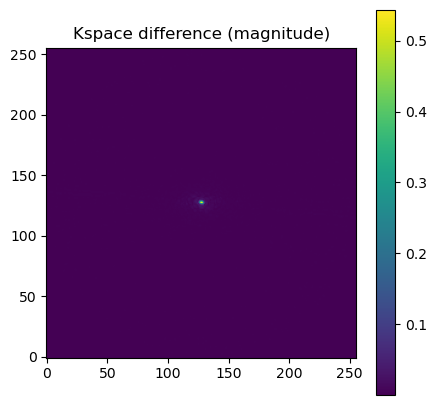

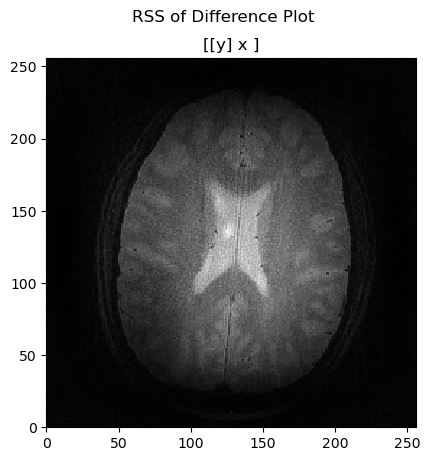

In [36]:
diff = zte_cart_kspace_imgtrip - kspace_cart_coils

plt.figure(figsize=(5,5))
im = plt.imshow(np.abs(diff[0]), origin='lower')
plt.title("Kspace difference (magnitude)")
plt.colorbar(im)
plt.show()


im_grid = sp.ifft(diff)
im_rss = np.sum(np.real(im_grid)**2, axis=0)**0.5

zte_img_rss = np.sum(np.abs(zte_img_grid)**2, axis=0)**0.5
#pl.ImagePlot(im_grid, z=0)
pl.ImagePlot(im_rss, title='RSS of Difference Plot')

#pl.ImagePlot(np.log1p(np.angle(diff)))

## Goal: Degridding

**Objectives:**

1. Go from cartesian to image with inverse FFT
2. Go back to radial with NUFFT

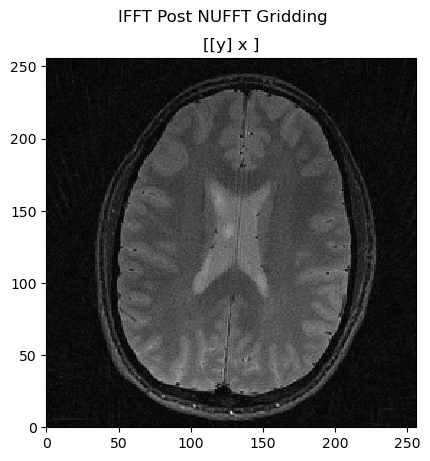

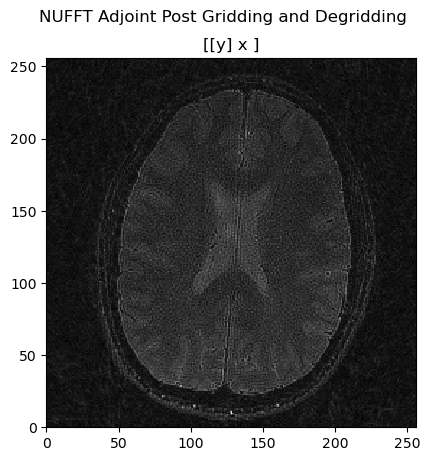

In [37]:
zte_cart_kspace_imgtrip = asm.nufft_gridding(kspace=zte_radial_kspace, coords=zte_radial_coords)

im_cart_grid = sp.ifft(zte_cart_kspace_imgtrip)
im_rss_cart = np.sum(np.abs(im_cart_grid)**2, axis=0)**0.5
pl.ImagePlot(im_rss_cart,title='IFFT Post NUFFT Gridding')

radial_post_imtrip = sp.nufft(im_cart_grid, zte_radial_coords, oversamp=1, width=10)

dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)
zte_img_grid = sp.nufft_adjoint(radial_post_imtrip * dcf, zte_radial_coords)
zte_img_rss = np.sum(np.abs(zte_img_grid)**2, axis=0)**0.5
pl.ImagePlot(zte_img_rss, title='NUFFT Adjoint Post Gridding and Degridding')

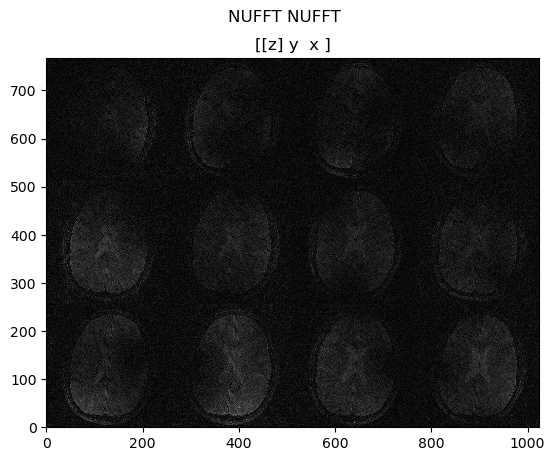

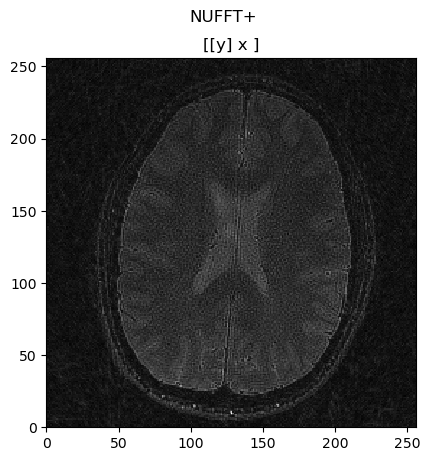

In [38]:
pl.ImagePlot(zte_img_grid, z=0,title='NUFFT NUFFT')
zte_img_rss1 = np.sum(np.abs(zte_img_grid)**2, axis=0)**0.5
pl.ImagePlot(zte_img_rss1,title='NUFFT+')

In [39]:
def nufft_degridding(cartesian_kspace, coords):
    n_coils = cartesian_kspace.shape[0]
    image = sp.ifft(cartesian_kspace, axes=(-2, -1))
    n_spokes = coords.shape[0]
    n_points = coords.shape[1]
    radial_kspace = np.zeros((n_coils, n_spokes, n_points),dtype=complex)
    for i in range(n_coils):
        radial_kspace[i] = sp.nufft(image[i], coord=coords)
    return radial_kspace

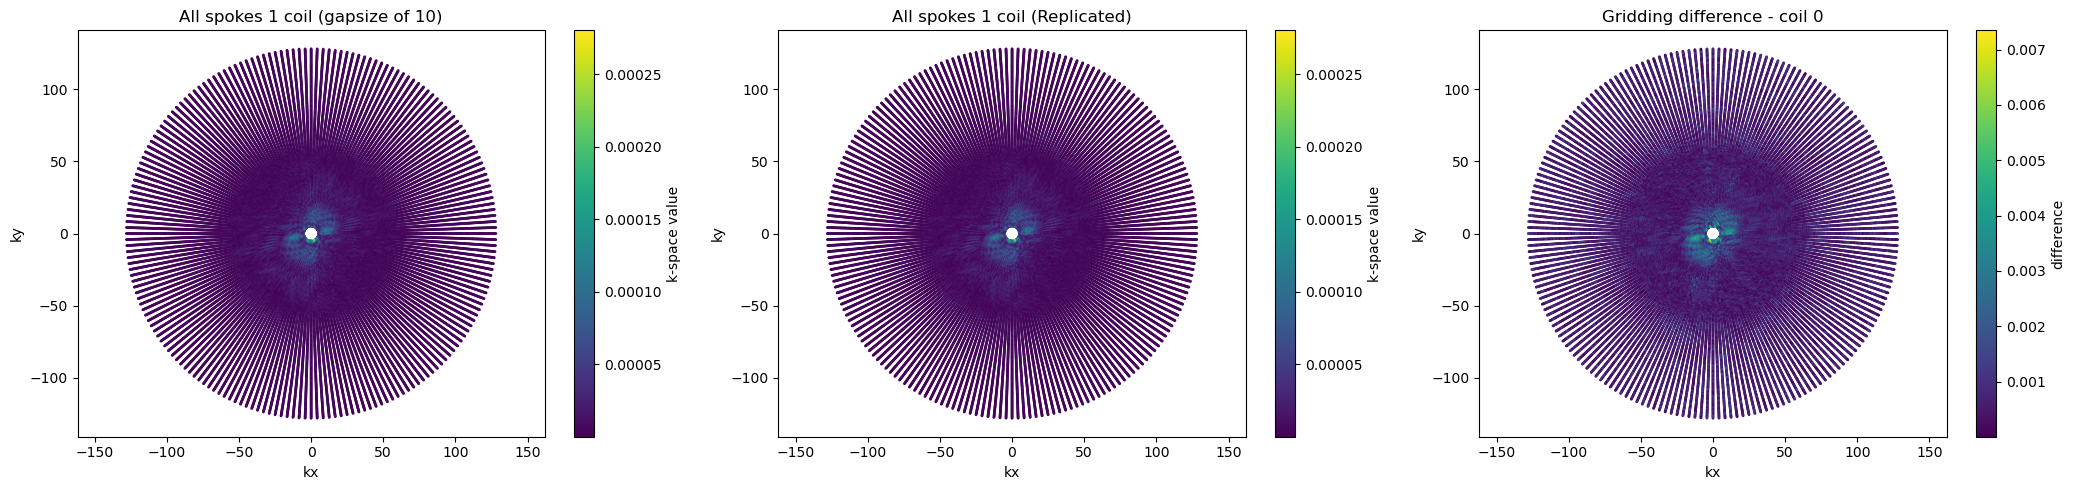

In [41]:
zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=10, undersampling_factor=1)

dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)
zte_img_grid = sp.nufft_adjoint(zte_radial_kspace * dcf, zte_radial_coords)

cartesian_post_nufft_adj = sp.fft(zte_img_grid)

degridded_kspace = nufft_degridding(cartesian_post_nufft_adj, zte_radial_coords)

all_coords = zte_radial_coords.reshape(-1,2)
all_kspace = zte_radial_kspace[0].reshape(-1)

all_coords = zte_radial_coords.reshape(-1,2)
all_kspace_gridded = degridded_kspace[0].reshape(-1)


all_coords = zte_radial_coords.reshape(-1, 2)
all_kspace = zte_radial_kspace[0].reshape(-1)
all_kspace_gridded = degridded_kspace[0].reshape(-1)

difference = all_kspace - all_kspace_gridded



fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(21, 5))


im0 = ax[0].scatter(all_coords[:, 0], all_coords[:, 1], c=np.abs(all_kspace), s=1)
ax[0].set_title('All spokes 1 coil (gapsize of 10)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
ax[0].axis('equal')
fig.colorbar(im0, ax=ax[0], label='k-space value')


im1 = ax[1].scatter(all_coords[:, 0], all_coords[:, 1], c=np.abs(all_kspace), s=1)
ax[1].set_title('All spokes 1 coil (Replicated)')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')
ax[1].axis('equal')
fig.colorbar(im1, ax=ax[1], label='k-space value')


im2 = ax[2].scatter(all_coords[:, 0], all_coords[:, 1], c=np.abs(difference), s=1)
ax[2].set_title('Gridding difference - coil 0')
ax[2].set_xlabel('kx')
ax[2].set_ylabel('ky')
ax[2].axis('equal')
fig.colorbar(im2, ax=ax[2], label='difference')

plt.tight_layout()
plt.show()

NameError: name 'image_pre_nufft' is not defined

In [ ]:
### Original Image
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)
zte_orig_grid = sp.nufft_adjoint(zte_radial_kspace * dcf, zte_radial_coords)
zte_orig_image = np.sum(np.abs(zte_orig_grid)**2, axis=0)**0.5


### Post gridding with sp.gridding
zte_cart_kspace_gridding = sp.gridding(zte_radial_kspace * dcf, zte_radial_coords, shape=(256, 256), kernel='kaiser_bessel', width=4)
zte_cart_kspace_gridding = np.fft.fftshift(zte_cart_kspace_gridding)


im_cart_grid = sp.ifft(zte_cart_kspace_imgtrip)
im_rss_cart = np.sum(np.abs(im_cart_grid)**2, axis=0)**0.5


### Post image - nufft on the cartesian image grid
radial_post_imtrip = sp.nufft(im_cart_grid, zte_radial_coords, oversamp=1, width=10)
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)

zte_img_grid = sp.nufft_adjoint(radial_post_imtrip * dcf, zte_radial_coords)
zte_img_rss = np.sum(np.abs(zte_img_grid)**2, axis=0)**0.5


#Div to find scaling problem
div = zte_img_rss / im_rss_cart

ValueError: cannot reshape array of size 566784 into shape (1,47232)

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 8))

im0 = ax[0].imshow(zte_orig_image, cmap='gray')
ax[0].set_title('Original image - no operations')
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(im_rss_cart, cmap='gray')
ax[1].set_title('IFFT Post NUFFT Gridding')
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(im_post_degrid_rss, cmap='gray')
ax[2].set_title('NUFFT Adjoint Post Gridding and Degridding')
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,5))

all_coords = zte_radial_coords.reshape(-1,2)
all_kspace = zte_radial_kspace[0].reshape(-1)

all_kspace_postim = radial_post_imtrip[0].reshape(-1)


im0 = ax[0].scatter(all_coords[:, 0], all_coords[:, 1], c=np.abs(all_kspace), s=1)
ax[0].set_title('All spokes 1 coil (original data)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
ax[0].axis('equal')
fig.colorbar(im0, ax=ax[0], label='k-space value')

im1 = ax[1].imshow(np.abs(kspace_cart_coils[0]))
ax[1].set_title('Cartesian (post nufft_adjoint)')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')
ax[1].axis('equal')
fig.colorbar(im1, ax=ax[1], label='k-space value')

im1 = ax[2].scatter(all_coords[:, 0], all_coords[:, 1], c=np.abs(all_kspace_postim), s=1)
ax[2].set_title('All spokes 1 coil (post operations)')
ax[2].set_xlabel('kx')
ax[2].set_ylabel('ky')
ax[2].axis('equal')
fig.colorbar(im1, ax=ax[2], label='k-space value')




plt.show()